In [9]:
%load_ext autoreload
%autoreload 2

import os
import sys

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
PROJ_PATH = '/home/dacslab/lasse_jantsch/circuit_discovery'
if PROJ_PATH not in sys.path:
    sys.path.insert(0, PROJ_PATH)

PLOT_DIR = './plots'
os.makedirs(PLOT_DIR, exist_ok=True)

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from transformers import AutoTokenizer, AutoModelForCausalLM
from experiments.mib.data_utils import MIBDataset

from nnsight import NNsight

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
MODEL_TO_ID = {
    'gpt2':    'gpt2',
    'qwen2.5': 'Qwen/Qwen2.5-0.5B',
    'gemma2':  'google/gemma-2-2b',
    # 'llama3':  'meta-llama/Llama-3.1-8B',
}

MODELS_TASKS = [
    ('qwen2.5', 'ioi'),
    ('qwen2.5', 'mcqa'),
    # ('gemma2', 'ioi'),
    # ('gpt2', 'ioi'),
]

NUM_EXAMPLES = 50

In [27]:
def collect_residuals(model, inputs, model_name='qwen2.5'):
    B, S = inputs['input_ids'].shape
    if model_name == 'gpt2':
        n_layer = model.config.n_layer
        model_dim = model.config.n_embd
        cache = {k: torch.zeros(n_layer, B, S, model_dim) for k in ['attn_out', 'mid', 'mlp_out', 'out']}

        with torch.no_grad(), model.trace(**inputs) as tracer:
            for i, layer in enumerate(model.transformer.h):
                cache["attn_out"][i] = layer.attn.output[0].save()
                cache["mid"][i] = layer.ln_2.input.save()
                cache["mlp_out"][i] = layer.mlp.output.save()
                cache["out"][i] = layer.output.save()
    elif model_name == 'gemma2':
        n_layer = model.config.num_hidden_layers
        model_dim = model.config.hidden_size
        cache = {k: torch.zeros(n_layer, B, S, model_dim) for k in ['attn_out', 'mid', 'mlp_out', 'out']}

        with torch.no_grad(), model.trace(**inputs) as tracer:
            for i, layer in enumerate(model.model.layers):
                cache["attn_out"][i] = layer.self_attn.output[0].save()
                cache["mid"][i] = layer.pre_feedforward_layernorm.input.save()
                cache["mlp_out"][i] = layer.mlp.output.save()
                cache["out"][i] = layer.output.save()
    else:
        n_layer = model.config.num_hidden_layers
        model_dim = model.config.hidden_size
        cache = {k: torch.zeros(n_layer, B, S, model_dim) for k in ['attn_out', 'mid', 'mlp_out', 'out']}

        with torch.no_grad(), model.trace(**inputs) as tracer:
            for i, layer in enumerate(model.model.layers):
                cache["attn_out"][i] = layer.self_attn.output[0].save()
                cache["mid"][i] = layer.post_attention_layernorm.input.save()
                cache["mlp_out"][i] = layer.mlp.output.save()
                cache["out"][i] = layer.output.save()
    return cache

In [71]:
def plot(model_name, task, attn_ration, mlp_ratio, res_attn_ratio, res_mlp_ratio):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    x = np.arange(len(attn_ration))

    def _band(ax, data:torch.Tensor, ls='-', x=x):
        mean = data.max(1).values.numpy()
        std  = data.std(1).numpy()
        ax.plot(x, mean, linewidth=1.5, linestyle=ls)
        ax.fill_between(x, mean - std, mean + std, alpha=0.15)

    _band(axes[0], attn_ration, ls='-')
    _band(axes[0], mlp_ratio,  ls='--')
    _band(axes[1], res_attn_ratio,  ls='-')
    _band(axes[1], res_mlp_ratio,   ls='--')

    for ax in axes:
        ax.set_xlabel('Layer')
        ax.grid(alpha=0.3)

    fig.suptitle(f"{model_name} - {task}")

    plt.legend()
    plt.show()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_3394199/61816314.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


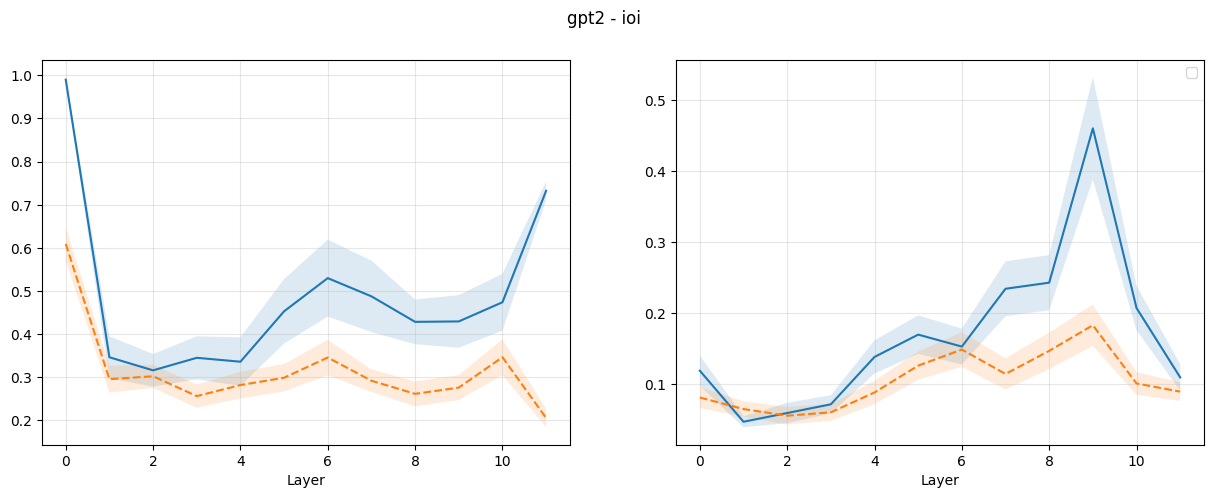

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

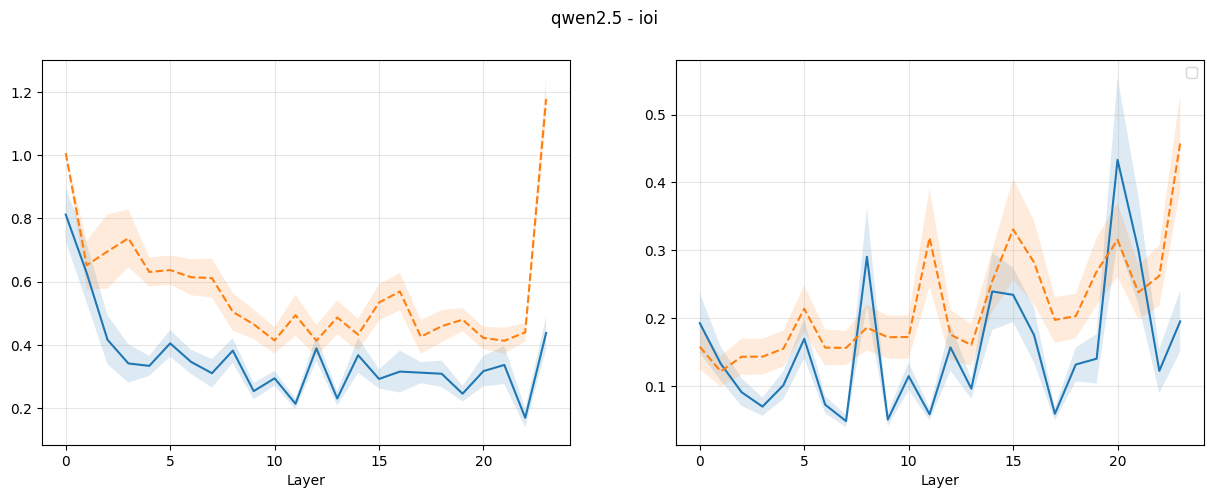

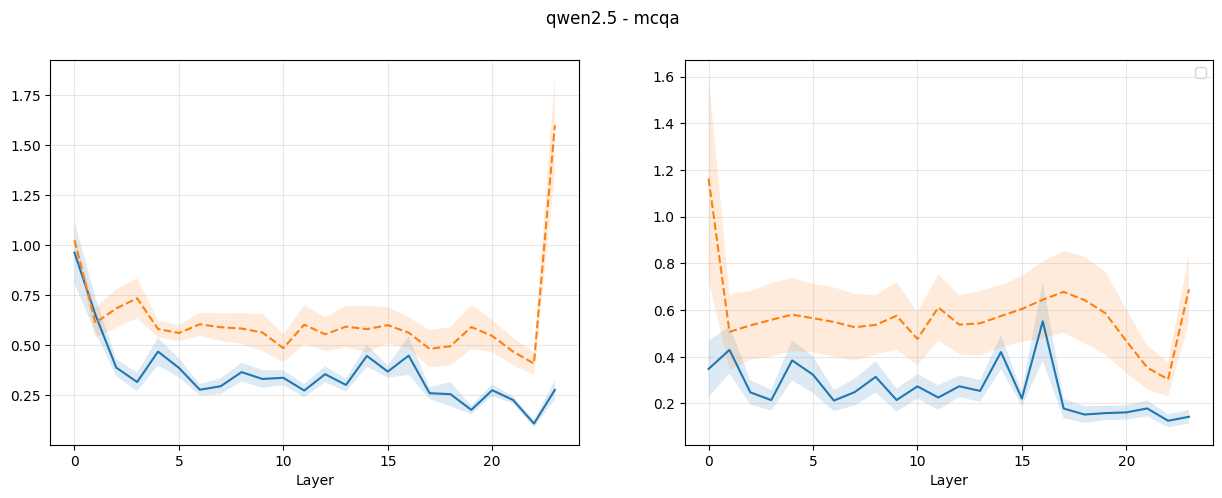

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

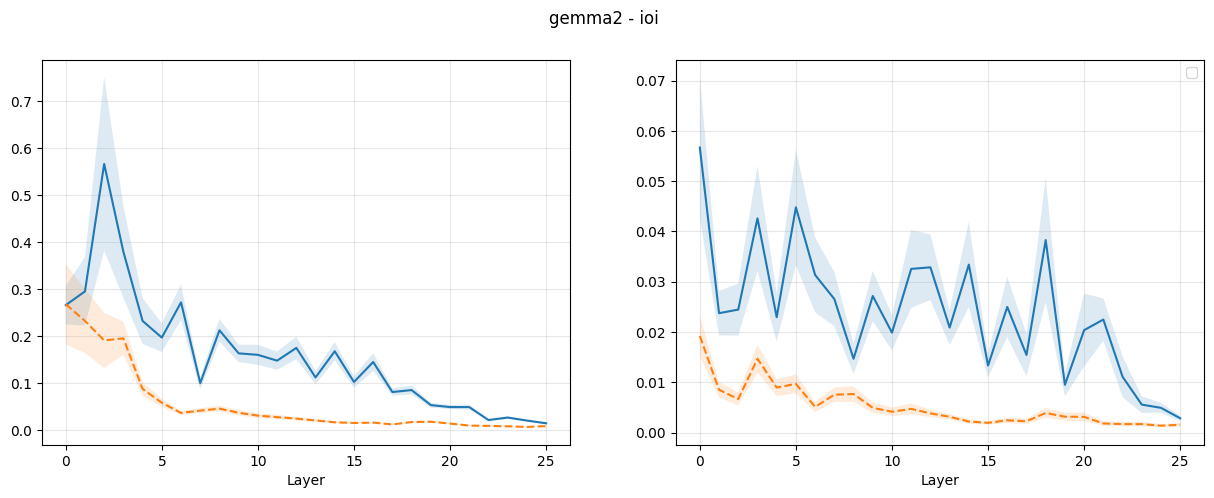

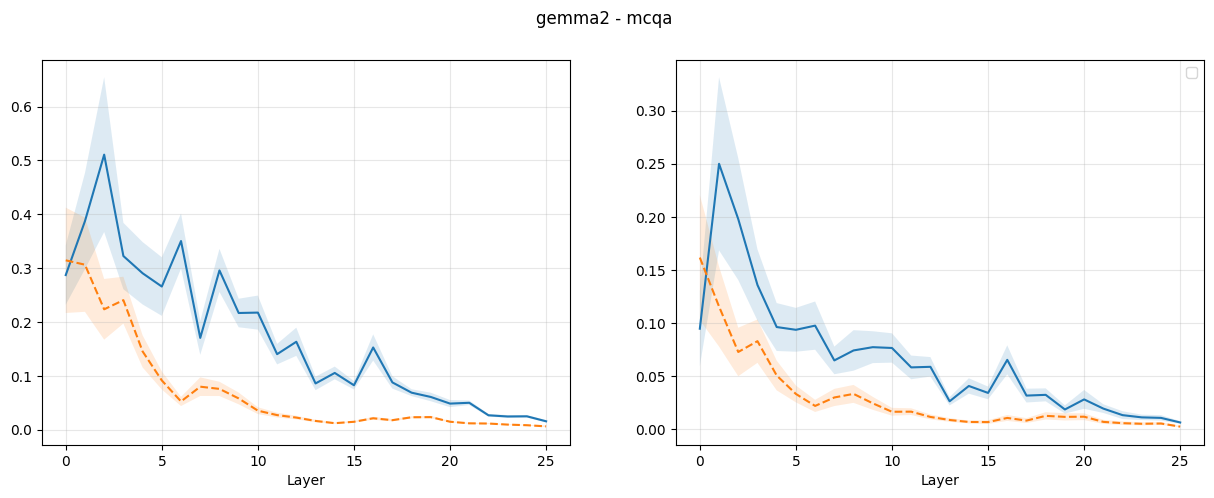

In [72]:
for model_name in MODEL_TO_ID:
    model_id = MODEL_TO_ID[model_name]

    model = AutoModelForCausalLM.from_pretrained(model_id, attn_implementation="eager", device_map='auto').eval()

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.padding_side = 'left'
    if model_id == 'gpt2':
        tokenizer.padding_side == 'right'
    if not tokenizer.pad_token:
        tokenizer.pad_token = tokenizer.eos_token
        
    # model = NNsight(model)
    model = NNsight(model)

    for task in ['ioi', 'mcqa']:
        if model_name == 'gpt2' and task == 'mcqa':
            continue
        dataset = MIBDataset(task, tokenizer, model_id, num_examples=None, split='test')
        dl = dataset.dataloader(10)

        clean_prompts, corrupted_prompts = next(iter(dl))[:2]
        inputs = tokenizer(clean_prompts + corrupted_prompts, return_tensors='pt', padding=True)

        B, S = inputs['input_ids'].shape

        non_identity_mask = (inputs['input_ids'][:B//2] != inputs['input_ids'][B//2:])
        first_non_identity = (non_identity_mask).int().argmax(-1)
        post_change_identity_mask = torch.arange(S)[None, :].repeat(B//2, 1) > first_non_identity[:, None]
        post_change_identity_mask[~inputs['attention_mask'][:B//2].bool()] = False

        residuals = collect_residuals(model, inputs, model_name)
        clean_residuals = {k: residuals[k][:, :B//2] for k in residuals}
        corrupt_residuals = {k: residuals[k][:, B//2:] for k in residuals}

        diff = {k: clean_residuals[k] - corrupt_residuals[k] for k in residuals}

        mid_norm = clean_residuals['mid'].norm(dim=-1)
        out_norm = clean_residuals['out'].norm(dim=-1)

        attn_ratio = (clean_residuals['attn_out'].norm(dim=-1) / mid_norm)[:, post_change_identity_mask]
        mlp_ratio = (clean_residuals['mlp_out'].norm(dim=-1) / out_norm)[:, post_change_identity_mask]
        
        res_attn_ratio = (diff['attn_out'].norm(dim=-1) / mid_norm)[:, post_change_identity_mask]
        res_mlp_ratio = (diff['mlp_out'].norm(dim=-1) / out_norm)[:, post_change_identity_mask]

        plot(model_name, task, attn_ratio, mlp_ratio, res_attn_ratio, res_mlp_ratio)
        

In [46]:
attn_ratio.mean((0, 1))

tensor([0.1595, 0.3784, 0.3798, 0.3881, 0.3932, 0.4048, 0.4098, 0.4111, 0.4166,
        0.4222, 0.4199, 0.4221, 0.4219, 0.4015, 0.4258, 0.4162, 0.4153, 0.4125,
        0.3874, 0.4350])

In [4]:
def _ms(x: torch.Tensor, mask: torch.Tensor):
    """Mean and std of per-token scalar over real (non-padding) tokens. x: (B, S)"""
    vals = x[mask]
    return vals.mean().item(), vals.std().item()


def compute_stats(res_in_c, res_mid_c, mlp_out_c,
                  res_in_p, res_mid_p, mlp_out_p, mask):
    """Per-layer statistics (mean +- std over real tokens x batch).

    (1) Clean norm proportions -- denominator is residual AFTER adding the module:
          attn_clean : ||attn|| / ||res_mid||   where res_mid = res_in + attn
          mlp_clean  : ||mlp||  / ||res_out||   where res_out = res_mid + mlp
    (2) Clean-corrupt delta norm proportions -- same metric on the delta residual:
          attn_diff  : ||delta_attn|| / ||delta_mid||
          mlp_diff   : ||delta_mlp||  / ||delta_out||
    (3) Cosine similarity of (res_in_clean - res_in_corrupt) to res_in_clean.
    """
    n = len(res_in_c)
    keys = ['attn_clean', 'mlp_clean', 'attn_diff', 'mlp_diff', 'cos']
    out = {f'{k}_{s}': np.zeros(n) for k in keys for s in ('mean', 'std')}
    out['n_layers'] = n

    for i in range(n):
        ric = res_in_c[i];  rmc = res_mid_c[i];  moc = mlp_out_c[i]  # (B, S, d)
        rip = res_in_p[i];  rmp = res_mid_p[i];  mop = mlp_out_p[i]

        roc = rmc + moc   # clean out-residual  (B, S, d)
        rop = rmp + mop   # corrupt out-residual

        attn_c = rmc - ric   # clean attn contribution  (B, S, d)
        attn_p = rmp - rip   # corrupt attn contribution

        # (1) clean norm proportions
        out['attn_clean_mean'][i], out['attn_clean_std'][i] = _ms(
            attn_c.norm(dim=-1) / rmc.norm(dim=-1).clamp(min=1e-8), mask)
        out['mlp_clean_mean'][i], out['mlp_clean_std'][i] = _ms(
            moc.norm(dim=-1) / roc.norm(dim=-1).clamp(min=1e-8), mask)

        # (2) clean-corrupt delta norm proportions
        delta_attn = attn_c - attn_p      # (B, S, d)
        delta_mlp  = moc    - mop
        delta_mid  = rmc    - rmp         # delta residual after attn
        delta_out  = roc    - rop         # delta residual after mlp

        out['attn_diff_mean'][i], out['attn_diff_std'][i] = _ms(
            delta_attn.norm(dim=-1) / delta_mid.norm(dim=-1).clamp(min=1e-8), mask)
        out['mlp_diff_mean'][i], out['mlp_diff_std'][i] = _ms(
            delta_mlp.norm(dim=-1) / delta_out.norm(dim=-1).clamp(min=1e-8), mask)

        # (3) cosine similarity
        cos = F.cosine_similarity(ric - rip, ric, dim=-1)   # (B, S)
        out['cos_mean'][i], out['cos_std'][i] = _ms(cos, mask)

    return out

In [6]:
all_results = {}

for model_name in MODEL_TO_ID:
    for task in ['ioi', 'mcqa']:
        model_id = MODEL_TO_ID[model_name]
        print(f'\n=== {model_name} / {task} ===')

        tokenizer = AutoTokenizer.from_pretrained(model_id)
        tokenizer.padding_side = 'right' if model_name == 'gpt2' else 'left'
        if not tokenizer.pad_token:
            tokenizer.pad_token = tokenizer.eos_token

        dtype = torch.float if model_name == 'gpt2' else torch.bfloat16
        model = AutoModelForCausalLM.from_pretrained(
            model_id, torch_dtype=dtype, attn_implementation='eager', device_map='auto'
        ).eval()
        device = next(model.parameters()).device

        dataset = MIBDataset(task, tokenizer, model_name, split='train', num_examples=NUM_EXAMPLES)
        dl = dataset.dataloader(NUM_EXAMPLES)
        clean_prompts, corrupt_prompts, _, _ = next(iter(dl))

        clean_inputs   = tokenizer(clean_prompts,   padding=True, return_tensors='pt').to(device)
        corrupt_inputs = tokenizer(corrupt_prompts, padding=True, return_tensors='pt').to(device)
        mask = clean_inputs['attention_mask'].bool().cpu()

        B, S = clean_inputs['input_ids'].shape
        print(f'  batch {B}x{S}')

        res_in_c, res_mid_c, mlp_out_c = collect_residuals(model, clean_inputs,   model_name)
        res_in_p, res_mid_p, mlp_out_p = collect_residuals(model, corrupt_inputs, model_name)

        all_results[(model_name, task)] = compute_stats(
            res_in_c, res_mid_c, mlp_out_c,
            res_in_p, res_mid_p, mlp_out_p,
            mask,
        )
        print(f'  {all_results[(model_name, task)]["n_layers"]} layers -- done')

        del model
        torch.cuda.empty_cache()


=== gpt2 / ioi ===


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  batch 50x24
  12 layers -- done

=== gpt2 / mcqa ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Filter:   0%|          | 0/10000 [00:00<?, ? examples/s]

  batch 50x24
  32 layers -- done

=== llama3 / mcqa ===


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Filter:   0%|          | 0/110 [00:00<?, ? examples/s]

  batch 50x38
  32 layers -- done


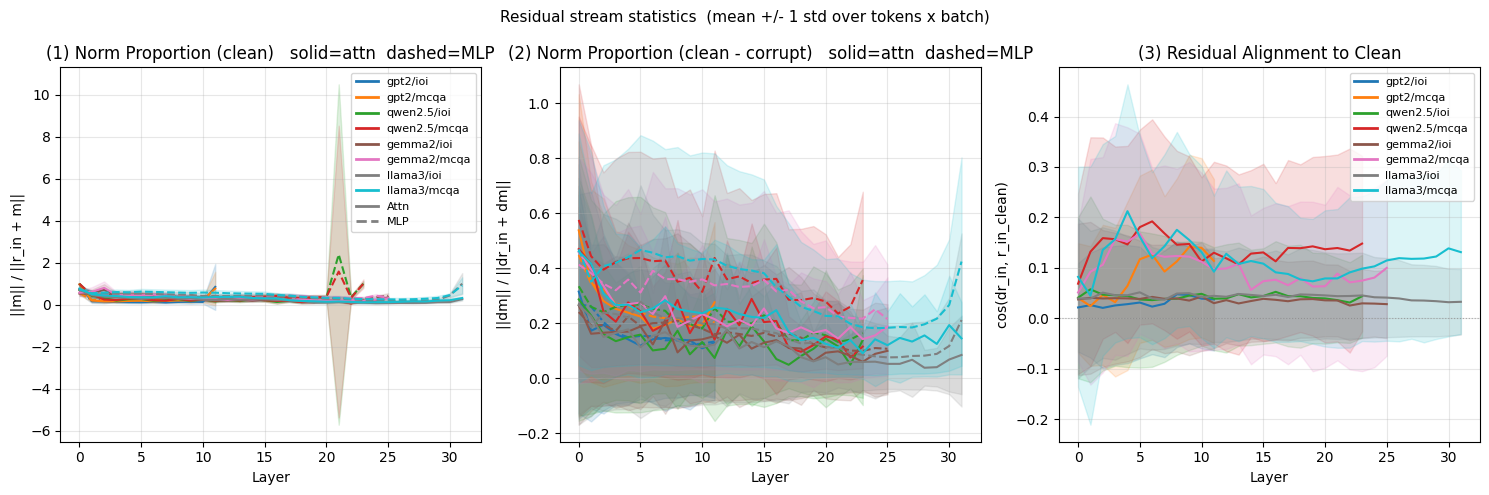

In [7]:
def plot_residual_stats(all_results, save_tag='residual_stats'):
    n_combos = len(all_results)
    colors = plt.cm.tab10(np.linspace(0, 0.9, n_combos))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, ((model_name, task), stats) in enumerate(all_results.items()):
        c = colors[idx]
        x = np.arange(stats['n_layers'])

        def _band(ax, key_base, ls='-', c=c, x=x, stats=stats):
            mean = stats[f'{key_base}_mean']
            std  = stats[f'{key_base}_std']
            ax.plot(x, mean, color=c, linewidth=1.5, linestyle=ls)
            ax.fill_between(x, mean - std, mean + std, color=c, alpha=0.15)

        _band(axes[0], 'attn_clean', ls='-')
        _band(axes[0], 'mlp_clean',  ls='--')
        _band(axes[1], 'attn_diff',  ls='-')
        _band(axes[1], 'mlp_diff',   ls='--')
        _band(axes[2], 'cos')

    for ax in axes:
        ax.set_xlabel('Layer')
        ax.grid(alpha=0.3)
    axes[2].axhline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)

    axes[0].set_ylabel('||m|| / ||r_in + m||')
    axes[0].set_title('(1) Norm Proportion (clean)   solid=attn  dashed=MLP')
    axes[1].set_ylabel('||dm|| / ||dr_in + dm||')
    axes[1].set_title('(2) Norm Proportion (clean - corrupt)   solid=attn  dashed=MLP')
    axes[2].set_ylabel('cos(dr_in, r_in_clean)')
    axes[2].set_title('(3) Residual Alignment to Clean')

    color_handles = [
        Line2D([0], [0], color=colors[i], linewidth=2, label=f'{mn}/{t}')
        for i, (mn, t) in enumerate(all_results)
    ]
    style_handles = [
        Line2D([0], [0], color='gray', linewidth=2, linestyle='-',  label='Attn'),
        Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='MLP'),
    ]
    axes[0].legend(handles=color_handles + style_handles, fontsize=8)
    axes[2].legend(handles=color_handles, fontsize=8)

    fig.suptitle('Residual stream statistics  (mean +/- 1 std over tokens x batch)', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'{save_tag}.png'), bbox_inches='tight', dpi=150)
    plt.show()


plot_residual_stats(all_results)